**Task-1**



In [ ]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/Housing.csv')

In [ ]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 545
Columns: 13


In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Task-2**

In [20]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64


In [21]:
print("Duplicates Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


In [22]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  \
0  13300000  7420         4          2        3        2   
1  12250000  8960         4          4        4        3   
2  12250000  9960         3          2        2        2   
3  12215000  7500         4          2        2        3   
4  11410000  7420         4          1        2        2   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  \
0                            False                         False   
1                            False                         False   
2                             True                         False   
3                            False                         False   
4                            False                         False   

   mainroad_yes  guestroom_yes  basement_yes  hotwaterheating_yes  \
0          True          False         False                False   
1          True          False         False                False   
2          True        

In [23]:
correlation = df.corr(numeric_only=True)

print(correlation["price"].sort_values(ascending=False))

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


**Task-3**

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (436, 13)
Testing Shape: (109, 13)


In [25]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Linear Regression Trained Successfully")

Linear Regression Trained Successfully


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² :", r2_lr)

MAE : 970043.4039201637
RMSE: 1324506.9600914386
R² : 0.6529242642153184


In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [28]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² :", r2_rf)

MAE : 1022355.4215596331
RMSE: 1402661.2024733487
R² : 0.6107565325972213


In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

print(comparison)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.022355e+06  1.402661e+06  0.610757


**Task-4**

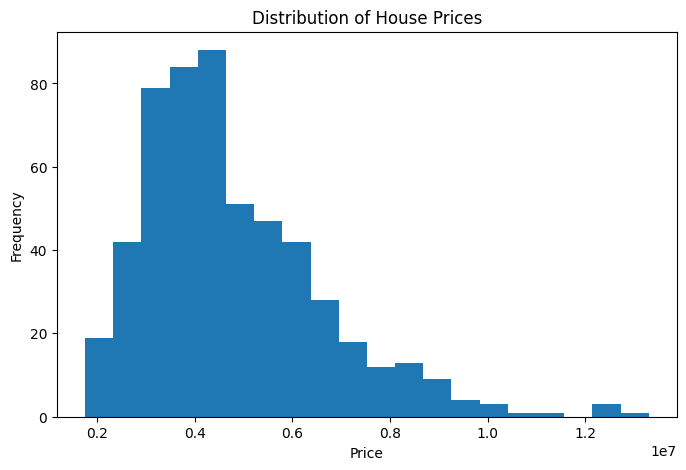

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=20)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

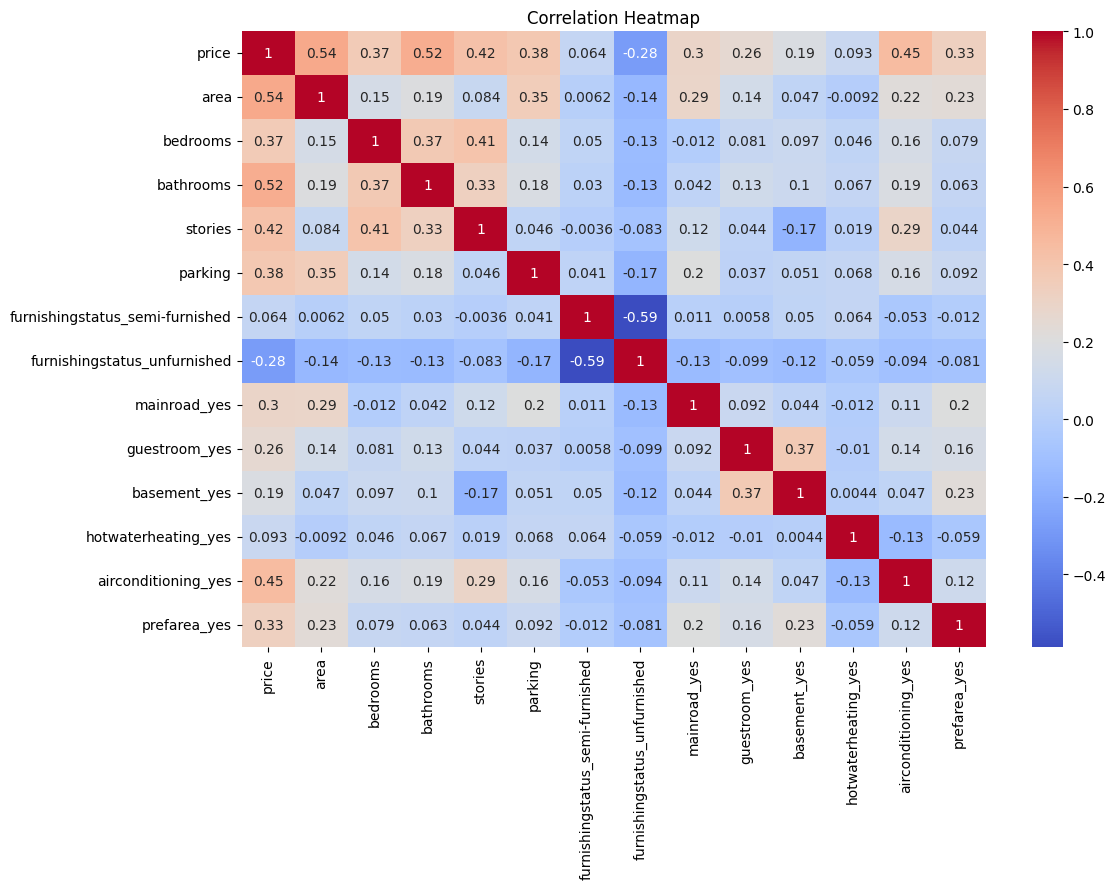

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

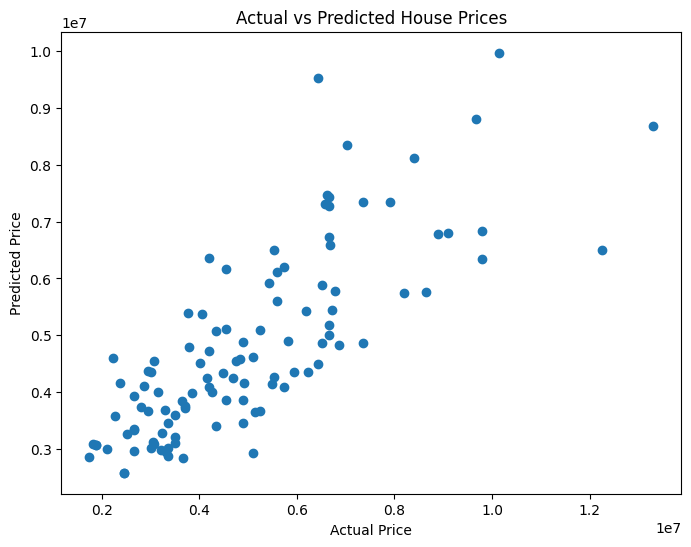

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

### Insights & Summary

Based on the correlation analysis and model results, the features that influenced house prices the most were area, number of bathrooms, air conditioning, parking availability, and the number of stories. These features showed a strong relationship with the target variable (price). The Random Forest Regressor performed better than the Linear Regression model, achieving a higher R² score and lower prediction errors, indicating that it could capture complex relationships in the data more effectively. One surprising observation was that some amenities, such as guest rooms and basement availability, had less impact on price than expected. Additionally, house area had a significantly stronger influence on price compared to most other features. Based on these findings, a real estate business should focus on properties with larger areas, sufficient parking, and modern amenities such as air conditioning, as these characteristics are more likely to increase property value and attract buyers.
